# 07 - Trend Structure
Detect impulse/retracement legs and BOS events using a pure state-machine algorithm.

Each leg alternates between **impulse** (trending move) and **retracement** (counter-trend pullback).
A **BOS** (Break Of Structure) is emitted each time a retracement ends and the trend resumes.

In [1]:
# Cell 1 - Setup: imports and data loading
%matplotlib inline

import sys
from pathlib import Path
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.core.features import normalize_candles, Candle
from src.adapters.local_data import load_ohlc_from_csv
from src.core.trend_structure import detect_structure

SYMBOL    = 'R_10'
TIMEFRAME = 'D'

processed_dir = ROOT / 'data' / 'processed'
csv_path = processed_dir / f'{SYMBOL}_{TIMEFRAME}.csv'

if csv_path.exists():
    candles = load_ohlc_from_csv(csv_path)
    print(f'Loaded : {csv_path.name}')
else:
    print('No CSV found -- generating synthetic daily data')
    np.random.seed(0)
    n   = 300
    mid = 1000 + np.cumsum(np.random.randn(n) * 5)
    base = datetime(2022, 1, 1)
    rows = [
        {
            'timestamp': (base + timedelta(days=i)).isoformat(),
            'open':  float(mid[i]),
            'high':  float(mid[i] + abs(np.random.randn() * 3)),
            'low':   float(mid[i] - abs(np.random.randn() * 3)),
            'close': float(mid[i] + np.random.randn()),
        }
        for i in range(n)
    ]
    candles = normalize_candles(rows)
    SYMBOL    = 'SYNTH'
    TIMEFRAME = 'D'

print(f'Candle count : {len(candles)}')
print(f'Date range   : {candles[0].timestamp.date()} to {candles[-1].timestamp.date()}')


Loaded : R_10_D.csv
Candle count : 366
Date range   : 2025-02-21 to 2026-02-21


In [2]:
# Cell 2 - Run detect_structure and summarise results
result = detect_structure(candles)

trend_val   = result['trend']
n_legs      = len(result['legs'])
n_bos       = len(result['bos_events'])
phase_val   = result['current_phase']
extreme_val = result['last_extreme']

print(f'Trend direction : {trend_val.upper()}')
print(f'Total legs      : {n_legs}')
print(f'BOS events      : {n_bos}')
print(f'Current phase   : {phase_val}')
print(f'Last extreme    : {extreme_val}')
print()

if result['legs']:
    hdr = (
        f"{'type':<14}  {'start_date':<12}  {'end_date':<12}"
        f"  {'start_p':>9}  {'end_p':>7}  {'bos_lvl':>9}"
    )
    print(hdr)
    print('-' * len(hdr))
    for leg in result['legs']:
        si   = leg['start_index']
        ei   = leg['end_index']
        sp   = leg['start_price']
        ep   = leg['end_price']
        bl   = leg['bos_level']
        s_dt = candles[si].timestamp.strftime('%Y-%m-%d')
        e_dt = candles[ei].timestamp.strftime('%Y-%m-%d') if ei is not None else 'open'
        sp_s = f'{sp:.2f}'
        ep_s = f'{ep:.2f}' if ep is not None else 'open'
        bl_s = f'{bl:.2f}' if bl is not None else 'None'
        print(
            f"{leg['type']:<14}  {s_dt:<12}  {e_dt:<12}"
            f"  {sp_s:>9}  {ep_s:>7}  {bl_s:>9}"
        )


Trend direction : DOWN
Total legs      : 74
BOS events      : 36
Current phase   : retracement
Last extreme    : 5103.586

type            start_date    end_date        start_p    end_p    bos_lvl
-------------------------------------------------------------------------
impulse         2025-02-21    2025-02-27      6496.01  6383.91       None
retracement     2025-02-27    2025-02-28      6383.91  6310.36       None
impulse         2025-02-28    2025-03-01      6310.36  6325.82    6328.80
retracement     2025-03-01    2025-03-02      6325.82  6238.77       None
impulse         2025-03-02    2025-03-03      6238.77  6269.82    6310.36
retracement     2025-03-03    2025-03-04      6269.82  6141.79       None
impulse         2025-03-04    2025-03-05      6141.79  6172.72    6238.77
retracement     2025-03-05    2025-03-06      6172.72  6123.55       None
impulse         2025-03-06    2025-03-07      6123.55  6172.32    6141.79
retracement     2025-03-07    2025-03-10      6172.32  6112.53 

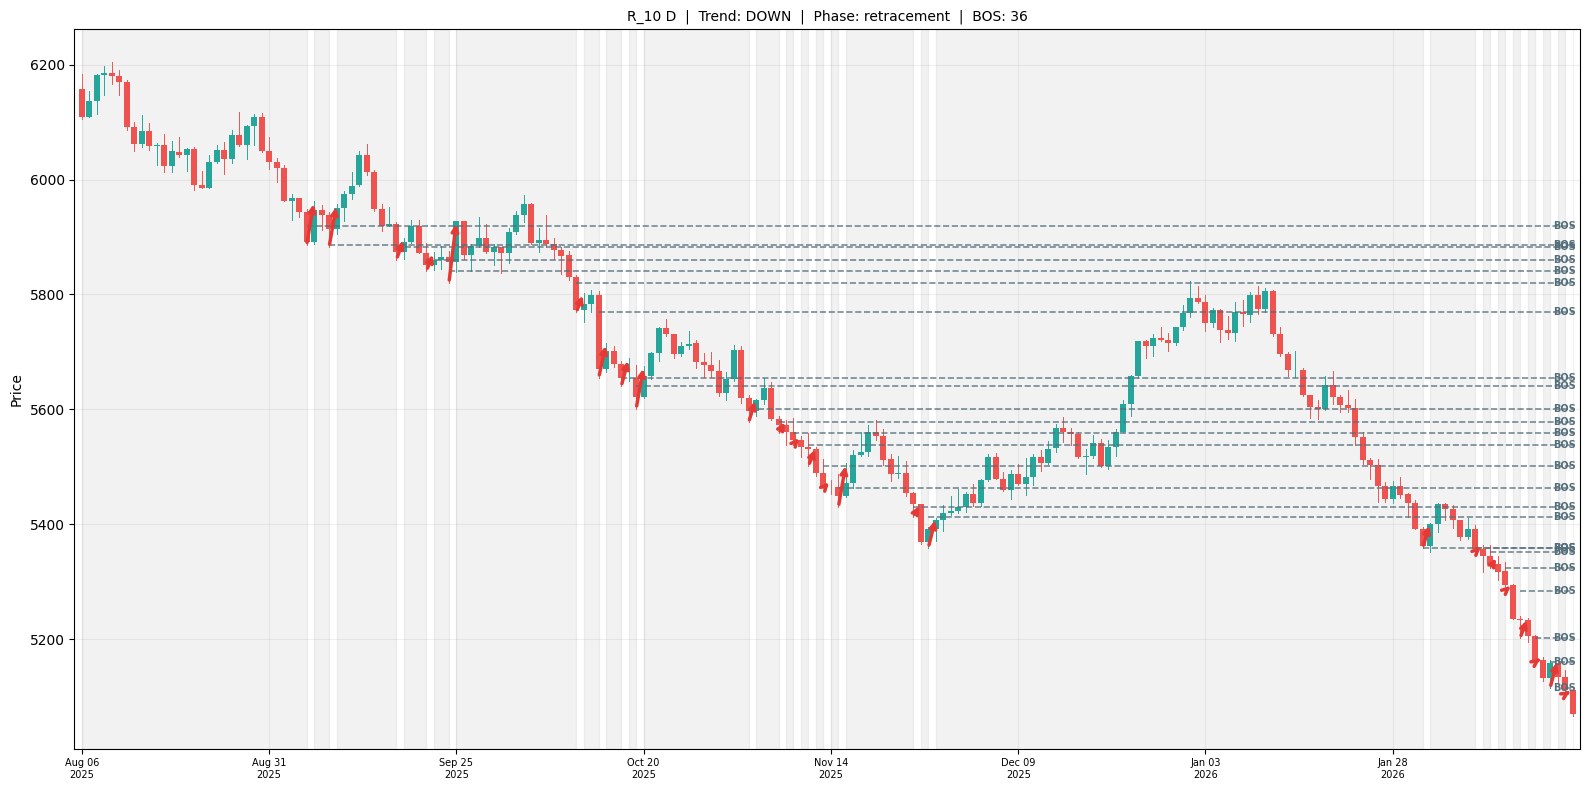

In [3]:
# Cell 3 - Candlestick chart: impulse arrows, retracement shading, BOS lines

def draw_structure_chart(ax, candles, result, title, window=200):
    n_feat  = len(candles)
    WINDOW  = min(window, n_feat)
    d_off   = n_feat - WINDOW
    disp    = candles[-WINDOW:]

    trend_d    = result['trend']
    UP_COLOR   = '#26a69a'
    DOWN_COLOR = '#ef5350'

    # -- Candlesticks --
    for i, c in enumerate(disp):
        col    = UP_COLOR if c.close >= c.open else DOWN_COLOR
        b_lo   = min(c.open, c.close)
        b_hi   = max(c.open, c.close)
        b_h    = max(b_hi - b_lo, (c.high - c.low) * 0.01)
        ax.plot([i, i], [c.low, c.high], color=col, linewidth=0.7, zorder=1)
        ax.add_patch(Rectangle(
            (i - 0.4, b_lo), 0.8, b_h,
            facecolor=col, edgecolor=col, linewidth=0, zorder=2,
        ))

    # -- Impulse arrows and retracement shading --
    for leg in result['legs']:
        si  = leg['start_index'] - d_off
        ei  = (leg['end_index'] - d_off) if leg['end_index'] is not None else WINDOW - 1
        sp  = leg['start_price']
        ep  = leg['end_price'] if leg['end_price'] is not None else disp[-1].close

        if ei < 0 or si >= WINDOW:
            continue
        si = max(si, 0)
        ei = min(ei, WINDOW - 1)

        if leg['type'] == 'impulse':
            arr_col = '#e53935' if trend_d == 'down' else '#43a047'
            if ei > si:
                ax.annotate(
                    '', xy=(ei, ep), xytext=(si, sp),
                    arrowprops=dict(arrowstyle='->', color=arr_col, lw=2.5),
                    zorder=5,
                )
        else:  # retracement
            ax.axvspan(si, ei, alpha=0.10, color='grey', zorder=0)

    # -- BOS horizontal dashed lines --
    for bos in result['bos_events']:
        di = bos['index'] - d_off
        if di < 0 or di >= WINDOW:
            continue
        bprice = bos['price']
        ax.plot(
            [di, WINDOW - 1], [bprice, bprice],
            color='#546e7a', linestyle='--', linewidth=1.2, alpha=0.8, zorder=4,
        )
        ax.text(
            WINDOW - 0.5, bprice, 'BOS', fontsize=7,
            ha='right', va='center', color='#546e7a', fontweight='bold', zorder=4,
        )

    tick_step = max(1, WINDOW // 8)
    tick_pos  = list(range(0, len(disp), tick_step))
    tick_lbl  = [disp[i].timestamp.strftime('%b %d\n%Y') for i in tick_pos]
    ax.set_xticks(tick_pos)
    ax.set_xticklabels(tick_lbl, fontsize=7)
    ax.set_xlim(-1, WINDOW)
    ax.set_ylabel('Price')
    ax.grid(True, alpha=0.2)
    ax.set_title(title, fontsize=10)


fig, ax = plt.subplots(figsize=(16, 8))
trend_s = result['trend'].upper()
phase_s = result['current_phase']
n_bos_s = len(result['bos_events'])
draw_structure_chart(
    ax, candles, result,
    f'{SYMBOL} {TIMEFRAME}  |  Trend: {trend_s}  |  Phase: {phase_s}  |  BOS: {n_bos_s}',
)
plt.tight_layout()
plt.show()


Loaded : R_10_1H.csv
Trend: UP  |  Legs: 10  |  BOS: 4  |  Phase: retracement


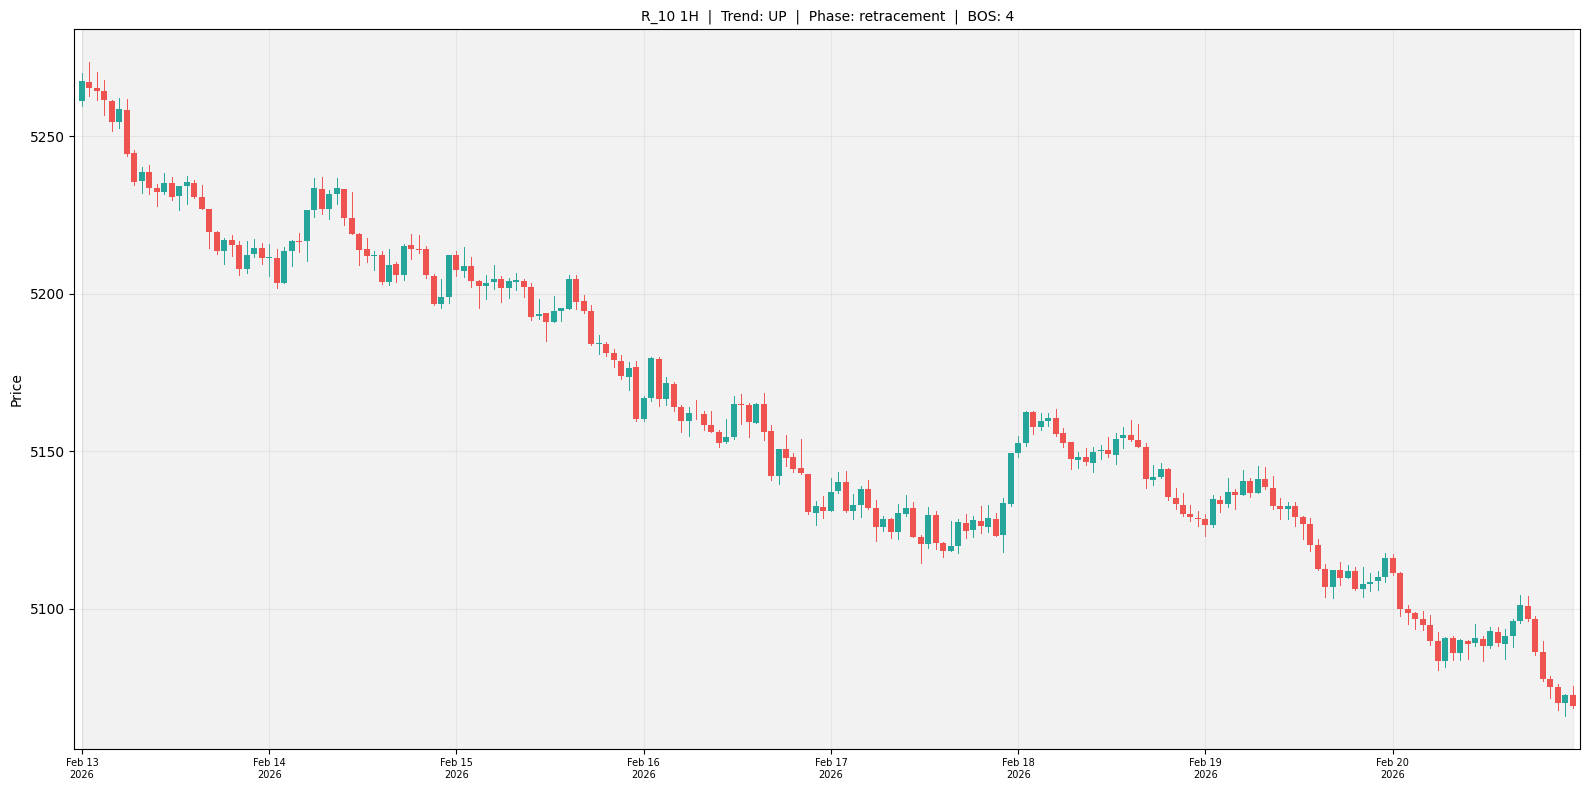

In [4]:
# Cell 4 - Repeat for R_10_1H.csv (or synthetic fallback)

SYMBOL_1H    = 'R_10'
TIMEFRAME_1H = '1H'
csv_path_1H  = processed_dir / f'{SYMBOL_1H}_{TIMEFRAME_1H}.csv'

if csv_path_1H.exists():
    candles_1H = load_ohlc_from_csv(csv_path_1H)
    print(f'Loaded : {csv_path_1H.name}')
else:
    print('No 1H CSV found -- generating synthetic 1H data')
    np.random.seed(42)
    n_1H    = 500
    mid_1H  = 5000 + np.cumsum(np.random.randn(n_1H) * 3)
    base_1H = datetime(2026, 1, 1)
    rows_1H = [
        {
            'timestamp': (base_1H + timedelta(hours=i)).isoformat(),
            'open':  float(mid_1H[i]),
            'high':  float(mid_1H[i] + abs(np.random.randn())),
            'low':   float(mid_1H[i] - abs(np.random.randn())),
            'close': float(mid_1H[i] + np.random.randn() * 0.5),
        }
        for i in range(n_1H)
    ]
    candles_1H = normalize_candles(rows_1H)
    SYMBOL_1H    = 'SYNTH'
    TIMEFRAME_1H = '1H'

result_1H = detect_structure(candles_1H)
t1h  = result_1H['trend'].upper()
p1h  = result_1H['current_phase']
b1h  = len(result_1H['bos_events'])
l1h  = len(result_1H['legs'])
print(f'Trend: {t1h}  |  Legs: {l1h}  |  BOS: {b1h}  |  Phase: {p1h}')

fig2, ax2 = plt.subplots(figsize=(16, 8))
draw_structure_chart(
    ax2, candles_1H, result_1H,
    f'{SYMBOL_1H} {TIMEFRAME_1H}  |  Trend: {t1h}  |  Phase: {p1h}  |  BOS: {b1h}',
)
plt.tight_layout()
plt.show()
